# NAB Anomaly Detection — Isolation Forest Baseline

**Goal:** Train and evaluate an Isolation Forest anomaly detector on `ec2_cpu_utilization_825cc2.csv`, 
using features identified during EDA (raw value, rolling mean, rolling std, point-to-point difference).
This notebook validates the modeling pipeline on a single file before generalizing to the full 
`ec2_cpu_utilization` group.

## Imports + cleaned data loading

In [4]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

from src.data_loading import load_series, load_anomaly_windows, clean_series

FILENAME = "ec2_cpu_utilization_825cc2.csv"

df = load_series(FILENAME)
df = clean_series(df)
windows = load_anomaly_windows(FILENAME)

# ground-truth label column
df["is_anomaly"] = 0
for start, end in windows:
    df.loc[start:end, "is_anomaly"] = 1

df.head()

,value,is_anomaly
timestamp,,
2014-04-10 00:04:00,91.958,0
2014-04-10 00:09:00,94.798,0
2014-04-10 00:14:00,92.208,0
2014-04-10 00:19:00,93.722,0
2014-04-10 00:24:00,93.042,0


## Build features identified during EDA: raw value, rolling stats, point-to-point difference

In [7]:
ROLLING_WINDOW = 12  # 1 hour at 5-min frequency

df["rolling_mean"] = df["value"].rolling(ROLLING_WINDOW).mean()
df["rolling_std"] = df["value"].rolling(ROLLING_WINDOW).std()
df["diff"] = df["value"].diff()

df_features = df.dropna().copy()

print(f"Rows before dropna: {len(df)} | after dropna: {len(df_features)}")
df_features.head()

Rows before dropna: 4034 | after dropna: 4023


,value,is_anomaly,rolling_mean,rolling_std,diff
timestamp,,,,,
2014-04-10 00:59:00,92.750,0,93.650833,1.224501,-1.458
2014-04-10 01:04:00,94.376,0,93.852333,1.114629,1.626
2014-04-10 01:09:00,92.792,0,93.685167,1.110326,-1.584
2014-04-10 01:14:00,91.666,0,93.640000,1.184429,-1.126
2014-04-10 01:19:00,87.542,0,93.125000,2.119772,-4.124


## Isolation forest training

In [8]:
FEATURE_COLS = ["value", "rolling_mean", "rolling_std", "diff"]

X = df_features[FEATURE_COLS]

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
)
model.fit(X)

df_features["anomaly_score"] = model.decision_function(X)
df_features["predicted_anomaly"] = (model.predict(X) == -1).astype(int)

print(f"Predicted anomalies: {df_features['predicted_anomaly'].sum()} / {len(df_features)}")

Predicted anomalies: 81 / 4023


### Model Notes

Isolation Forest is trained with `contamination=0.02`, estimated from the labeled anomaly window duration relative to the full series length, and `random_state=42` for reproducibility.

## Predictions vs ground truth

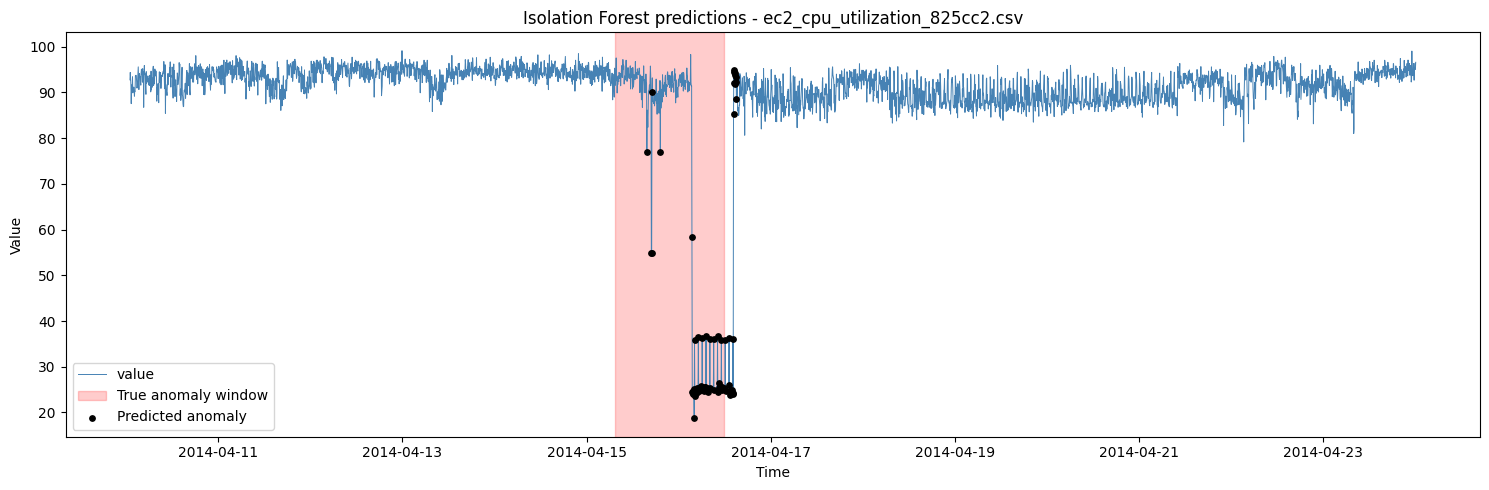

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_features.index, df_features["value"], linewidth=0.7, color="steelblue", label="value")

# Ground truth 
for start, end in windows:
    ax.axvspan(start, end, color="red", alpha=0.2, label="True anomaly window")

# Model predictions 
predicted = df_features[df_features["predicted_anomaly"] == 1]
ax.scatter(predicted.index, predicted["value"], color="black", s=15, zorder=5, label="Predicted anomaly")

ax.set_title(f"Isolation Forest predictions - {FILENAME}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

### Isolation Forest Predictions

The Isolation Forest successfully identifies most abnormal observations, with predicted anomalies concentrated almost entirely within or around the labeled anomaly window.

- The isolated CPU drops and the low-CPU plateau are correctly detected.
- Only a few additional detections appear during the recovery phase, likely due to the abrupt transition back to normal behavior.
- No significant false positives are observed during the rest of the time series, indicating a strong baseline performance.

Although **81 points (~2%)** are classified as anomalies, this proportion is expected since `contamination=0.02`. Therefore, the spatial distribution of the detected anomalies is more informative than their total number.

## Precision/Recall/F1

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = df_features["is_anomaly"]
y_pred = df_features["predicted_anomaly"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("(rows = true [normal, anomaly], cols = predicted [normal, anomaly])")

Precision: 0.716
Recall:    0.169
F1-score:  0.274

Confusion matrix:
[[3657   23]
 [ 285   58]]
(rows = true [normal, anomaly], cols = predicted [normal, anomaly])


### Metrics Interpretation

Precision (0.716) is solid — few false positives among predicted anomalies. Recall (0.169) is low but expected: the model only flags points that clearly deviate from the normal value distribution, not every point inside the labeled window (e.g. the early, less extreme part of the anomaly). This point-level evaluation is stricter than the official NAB score, which rewards any detection within a window rather than every individual point.

## Official NAB Scoring

This section integrates the Isolation Forest detector into the official NAB benchmark 
(cloned externally, not part of this repo) and runs the full detect/optimize/score/normalize 
pipeline. The setup is idependant, safe to re-run.

In [15]:
from pathlib import Path

NAB_PATH = Path("../../NAB").resolve()
assert NAB_PATH.exists(), f"NAB path not found: {NAB_PATH}"

DETECTOR_CODE = '''
import numpy as np
from sklearn.ensemble import IsolationForest

from nab.detectors.base import AnomalyDetector


class IsolationForestDetector(AnomalyDetector):
    """
    Isolation Forest baseline for the NAB benchmark.

    Isolation Forest is a batch algorithm, not a streaming one. So the
    model is trained once on the full file inside initialize(), and the
    precomputed anomaly scores are simply replayed row by row through
    handleRecord(), as required by the NAB detector interface.
    """

    def __init__(self, *args, **kwargs):
        super(IsolationForestDetector, self).__init__(*args, **kwargs)
        self.scores = None
        self.rowIndex = 0

    def initialize(self):
        data = self.dataSet.data.copy()

        window = 12  # 1 hour at 5-min frequency
        data["rolling_mean"] = data["value"].rolling(window).mean()
        data["rolling_std"] = data["value"].rolling(window).std()
        data["diff"] = data["value"].diff()
        data = data.bfill()

        features = data[["value", "rolling_mean", "rolling_std", "diff"]]

        model = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
        model.fit(features)

        raw_scores = -model.decision_function(features)
        min_score, max_score = raw_scores.min(), raw_scores.max()
        self.scores = (raw_scores - min_score) / (max_score - min_score)

    def handleRecord(self, inputData):
        score = float(self.scores[self.rowIndex])
        self.rowIndex += 1
        return [score]
'''

detector_dir = NAB_PATH / "nab" / "detectors" / "isolation_forest"
detector_dir.mkdir(parents=True, exist_ok=True)
(detector_dir / "__init__.py").touch(exist_ok=True)
(detector_dir / "isolation_forest_detector.py").write_text(DETECTOR_CODE)

print(f"Detector written to {detector_dir}")

Detector written to C:\Users\nouveaucompte\NAB\nab\detectors\isolation_forest


In [16]:
RUN_PY_MARKER = 'if "isolationForest" in args.detectors:'
RUN_PY_BLOCK = (
    '  if "isolationForest" in args.detectors:\n'
    '        from nab.detectors.isolation_forest.isolation_forest_detector import (\n'
    '            IsolationForestDetector)\n'
)

run_py = NAB_PATH / "run.py"
content = run_py.read_text()
if RUN_PY_MARKER not in content:
    content = content.replace(
        "  if args.skipConfirmation or checkInputs(args):",
        RUN_PY_BLOCK + "\n  if args.skipConfirmation or checkInputs(args):"
    )
    run_py.write_text(content)
    print("Patched run.py")
else:
    print("run.py already patched")

LABELER_OLD = 'labels["label"].values[indices.values] = 1'
LABELER_NEW = 'labels.loc[indices, "label"] = 1'

labeler_py = NAB_PATH / "nab" / "labeler.py"
content = labeler_py.read_text()
if LABELER_OLD in content:
    content = content.replace(LABELER_OLD, LABELER_NEW)
    labeler_py.write_text(content)
    print("Patched labeler.py (pandas read-only fix)")
else:
    print("labeler.py already patched")

run.py already patched
labeler.py already patched


In [17]:
import json

with open(NAB_PATH / "labels" / "combined_windows.json") as f:
    all_windows = json.load(f)

key = f"realAWSCloudwatch/{FILENAME}"  # reuses FILENAME already defined earlier in this notebook
subset = {key: all_windows[key]}

with open(NAB_PATH / "labels" / "combined_windows_test.json", "w") as f:
    json.dump(subset, f, indent=4)

print(subset)

{'realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv': [['2014-04-15 07:24:00.000000', '2014-04-16 11:54:00.000000']]}


In [18]:
import subprocess

result = subprocess.run(
    [
        "python", "run.py",
        "-d", "isolationForest",
        "--detect", "--optimize", "--score", "--normalize",
        "--dataDir", "data_test",
        "--windowsFile", "labels/combined_windows_test.json",
        "--skipConfirmation",
    ],
    cwd=NAB_PATH,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)


Running detection step
0: Beginning detection with isolationForest for realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv
. . . . . 0: Completed processing 4032 records at 2026-07-22 22:27:24.567066
0: Results have been written to C:\Users\nouveaucompte\NAB\results\isolationForest\realAWSCloudwatch\isolationForest_ec2_cpu_utilization_825cc2.csv

Running optimize step
Optimizer found a max score of 0.717472720985831 with anomaly threshold 0.8567388346119605.
Optimizer found a max score of 0.6076683567746779 with anomaly threshold 0.9561501716212052.
Optimizer found a max score of 0.717472720985831 with anomaly threshold 0.8567388346119605.

Running scoring step
isolationForest detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\isolationForest\isolationForest_standard_scores.csv
isolationForest detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\isolationForest\isolationForest_reward_low_FP_rate_scores.csv
isolationForest detector benchmark scores 

### Single-File NAB Score

Standard: 99.76, Reward low FP: 99.66, Reward low FN: 99.88. This near-perfect score reflects an easy-to-detect anomaly (a sharp regime change) on a single file, and is not representative of performance across the full dataset diversity — see the extension to 17 files below.

## Extend to the 17 CPU files

In [19]:
import shutil

source_dir = NAB_PATH / "data" / "realAWSCloudwatch"
dest_dir = NAB_PATH / "data_test" / "realAWSCloudwatch"
dest_dir.mkdir(parents=True, exist_ok=True)

csv_files = list(source_dir.glob("*.csv"))
for csv_file in csv_files:
    shutil.copy(csv_file, dest_dir / csv_file.name)

print(f"Copied {len(csv_files)} files to {dest_dir}")

Copied 17 files to C:\Users\nouveaucompte\NAB\data_test\realAWSCloudwatch


In [20]:
with open(NAB_PATH / "labels" / "combined_windows.json") as f:
    all_windows = json.load(f)

subset = {
    k: v for k, v in all_windows.items()
    if k.startswith("realAWSCloudwatch/")
}

with open(NAB_PATH / "labels" / "combined_windows_realAWS.json", "w") as f:
    json.dump(subset, f, indent=4)

print(f"{len(subset)} files included:")
for k in subset:
    print(" -", k)

17 files included:
 - realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv
 - realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv
 - realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv
 - realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv
 - realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv
 - realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv
 - realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv
 - realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv
 - realAWSCloudwatch/ec2_disk_write_bytes_1ef3de.csv
 - realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv
 - realAWSCloudwatch/ec2_network_in_257a54.csv
 - realAWSCloudwatch/ec2_network_in_5abac7.csv
 - realAWSCloudwatch/elb_request_count_8c0756.csv
 - realAWSCloudwatch/grok_asg_anomaly.csv
 - realAWSCloudwatch/iio_us-east-1_i-a2eb1cd9_NetworkIn.csv
 - realAWSCloudwatch/rds_cpu_utilization_cc0c53.csv
 - realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv


In [22]:
result = subprocess.run(
    [
        "python", "run.py",
        "-d", "isolationForest",
        "--optimize", "--score", "--normalize",
        "--dataDir", "data_test",
        "--windowsFile", "labels/combined_windows_realAWS.json",
        "--skipConfirmation",
    ],
    cwd=NAB_PATH,
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)


Running optimize step
Optimizer found a max score of 1.3074492879727029 with anomaly threshold 0.9176623252411246.
Optimizer found a max score of -4.616581655978992 with anomaly threshold 0.973040905968864.
Optimizer found a max score of -7.596305959965165 with anomaly threshold 0.8973404202365756.

Running scoring step
isolationForest detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\isolationForest\isolationForest_standard_scores.csv
isolationForest detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\isolationForest\isolationForest_reward_low_FP_rate_scores.csv
isolationForest detector benchmark scores written to C:\Users\nouveaucompte\NAB\results\isolationForest\isolationForest_reward_low_FN_rate_scores.csv

Running score normalization step
Final score for 'isolationForest' detector on 'standard' profile = 80.35
Final score for 'isolationForest' detector on 'reward_low_FP_rate' profile = 76.29
Final score for 'isolationForest' detector on '

### 17-File NAB Score

Standard: 80.35, Reward low FP: 76.29, Reward low FN: 85.65. As expected, the score drops substantially compared to the single-file run, since the dataset now includes files with more subtle or atypical anomaly patterns (see EDA cross-file comparison). This is a more representative baseline score.

In [25]:
import pandas as pd

scores_path = NAB_PATH / "results" / "isolationForest" / "isolationForest_standard_scores.csv"
scores_df = pd.read_csv(scores_path)

per_file_scores = scores_df[scores_df["File"].notna()].copy()
per_file_scores = per_file_scores.sort_values("Score")
per_file_scores[["File", "Score", "TP", "FP", "FN", "TN"]]

,File,Score,TP,FP,FN,TN
14,realAWSCloudwatch/iio_us-east-1_i-a2eb1cd9_Net...,-2.110000,0,1,126,930
13,realAWSCloudwatch/grok_asg_anomaly.csv,-1.686287,5,5,460,3458
6,realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv,-1.430000,0,13,0,3415
9,realAWSCloudwatch/ec2_disk_write_bytes_c0d644.csv,-0.947505,4,14,401,3009
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,-0.350998,1,0,401,3026
8,realAWSCloudwatch/ec2_disk_write_bytes_1ef3de.csv,-0.228958,4,10,469,3538
0,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,-0.138449,2,0,400,3026
16,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,-0.138449,4,0,398,3026
1,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,0.432516,3,4,399,3022
3,realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv,0.544401,1,4,402,3021


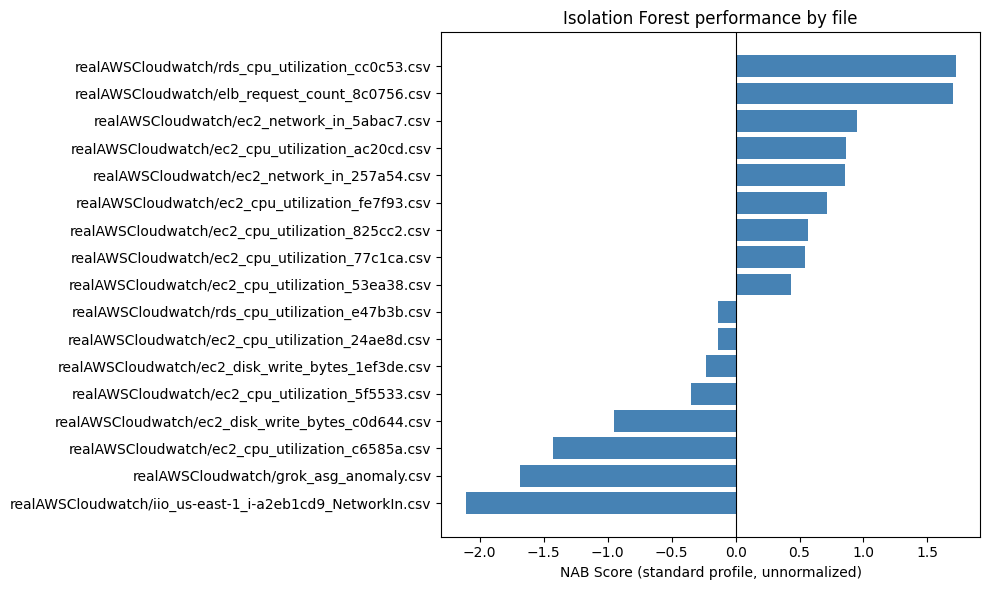

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(per_file_scores["File"], per_file_scores["Score"], color="steelblue")
ax.set_xlabel("NAB Score (standard profile, unnormalized)")
ax.set_title("Isolation Forest performance by file")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Per-File Analysis

Three files score negative (worse than detecting nothing): `iio_us-east-1_i-a2eb1cd9_NetworkIn.csv` (very short file, 1243 records), `grok_asg_anomaly.csv`, and `ec2_cpu_utilization_c6585a.csv`. These highlight the limits of applying a single fixed feature set and contamination value uniformly across files with very different normal behaviors.

## Summary 

Isolation Forest establishes a solid, reproducible baseline (NAB standard score: 80.35 on 17 `realAWSCloudwatch` files), integrated with the official NAB scoring pipeline. 